In [ ]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib pandas

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", __import__("torchvision").__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / (1024 ** 3),
            2
        ),
        "GB"
    )
else:
    print("WARNING: GPU is not available.")
    print("Go to Runtime > Change runtime type > T4 GPU.")

Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 2
LEARNING_RATE = 0.0005
NUM_WORKERS = 2
SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Image size: 224
Batch size: 64
Epochs: 2
Learning rate: 0.0005


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created.")

Image transformations created.


In [ ]:
train_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

val_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=val_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_transform
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)
print("Total training images:", len(train_dataset_full))
print("Total testing images:", len(test_dataset))

100%|██████████| 170M/170M [31:05<00:00, 91.4kB/s]


Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total training images: 50000
Total testing images: 10000


In [ ]:
indices = np.arange(
    len(train_dataset_full)
)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.10,
    random_state=SEED,
    stratify=train_dataset_full.targets
)

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    val_dataset_full,
    val_indices
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Training images: 45000
Validation images: 5000
Testing images: 10000


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


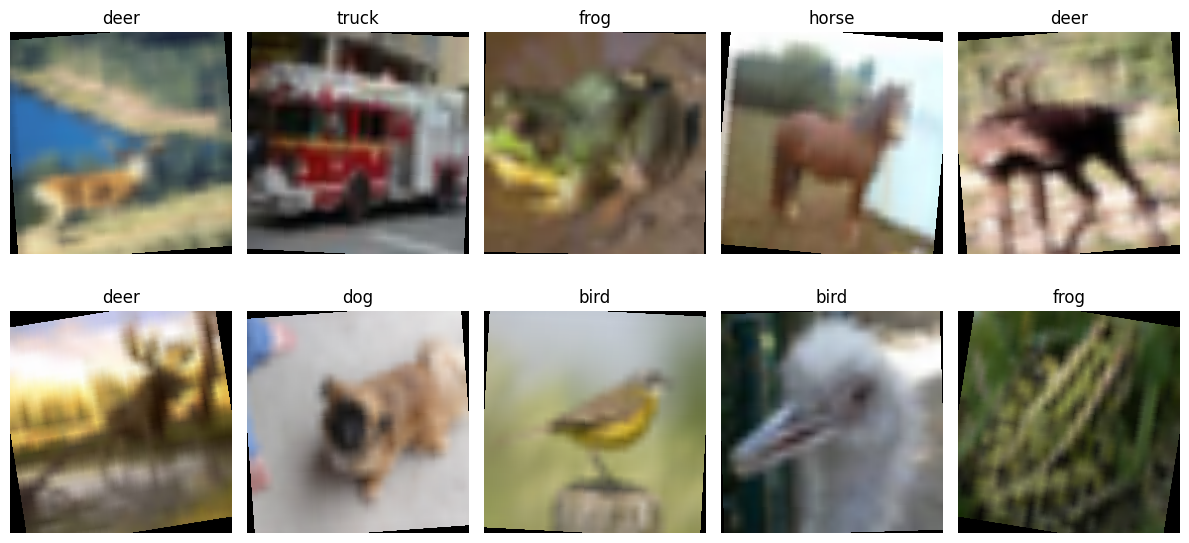

In [ ]:
def denormalize(image):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(image, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(10):

    image = denormalize(
        images[i]
    )

    image = image.permute(
        1, 2, 0
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        class_names[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def create_model(model_name):

    if model_name == "AlexNet":

        model = models.alexnet(
            weights=models.AlexNet_Weights.DEFAULT
        )

        # Freeze pretrained feature extractor
        for parameter in model.features.parameters():
            parameter.requires_grad = False

        # Replace final classifier
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )


    elif model_name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        # Freeze pretrained feature extractor
        for parameter in model.features.parameters():
            parameter.requires_grad = False

        # Replace final classifier
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )


    elif model_name == "ResNet50":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        # Freeze pretrained layers
        for parameter in model.parameters():
            parameter.requires_grad = False

        # Replace final classifier
        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif model_name == "EfficientNetB0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze feature extractor
        for parameter in model.features.parameters():
            parameter.requires_grad = False

        # Replace final classifier
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )


    else:
        raise ValueError(
            "Invalid model name"
        )

    return model

In [ ]:
model_names = [
    "AlexNet",
    "VGG16",
    "ResNet50",
    "EfficientNetB0"
]

print("Models selected for transfer learning:")

for name in model_names:
    print("-", name)

Models selected for transfer learning:
- AlexNet
- VGG16
- ResNet50
- EfficientNetB0


In [ ]:
test_model = create_model(
    "AlexNet"
)

test_model = test_model.to(
    device
)

print("AlexNet created successfully.")

del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 184MB/s]


AlexNet created successfully.


In [ ]:

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=2
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=LEARNING_RATE
    )

    history = {
        "train_accuracy": [],
        "val_accuracy": [],
        "train_loss": [],
        "val_loss": []
    }

    best_accuracy = 0.0
    best_weights = copy.deepcopy(
        model.state_dict()
    )

    start_time = time.time()

    for epoch in range(epochs):

        print(
            f"\nEpoch {epoch + 1}/{epochs}"
        )

        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images = images.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )
            optimizer.zero_grad()
            outputs = model(
                images
            )
            loss = criterion(
                outputs,
                labels
            )
            loss.backward()
            optimizer.step()
            running_loss += (
                loss.item() *
                images.size(0)
            )
            _, predicted = torch.max(
                outputs,
                1
            )
            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()
        train_loss = (
            running_loss / total
        )
        train_accuracy = (
            correct / total
        )
        # Validation
        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(
                    device,
                    non_blocking=True
                )
                labels = labels.to(
                    device,
                    non_blocking=True
                )
                outputs = model(
                    images
                )
                loss = criterion(
                    outputs,
                    labels
                )
                val_loss_total += (
                    loss.item() *
                    images.size(0)
                )
                _, predicted = torch.max(
                    outputs,
                    1
                )
                val_total += labels.size(0)
                val_correct += (
                    predicted == labels
                ).sum().item()
        val_loss = (
            val_loss_total /
            val_total
        )
        val_accuracy = (
            val_correct /
            val_total
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f}"
        )

        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_accuracy > best_accuracy:

            best_accuracy = val_accuracy

            best_weights = copy.deepcopy(
                model.state_dict()
            )

    training_time = (
        time.time() - start_time
    ) / 60

    model.load_state_dict(
        best_weights
    )

    return model, history, training_time

In [ ]:
def evaluate_model(
    model,
    test_loader
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return (
        np.array(y_true),
        np.array(y_pred),
        accuracy,
        precision,
        recall,
        f1
    )

In [ ]:
models_dict = {}
histories = {}
results = {}

for model_name in model_names:

    print("\n" + "=" * 70)
    print("Training:", model_name)
    print("=" * 70)

    model = create_model(
        model_name
    )

    model = model.to(
        device
    )

    model, history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS
    )

    (
        y_true,
        y_pred,
        accuracy,
        precision,
        recall,
        f1
    ) = evaluate_model(
        model,
        test_loader
    )

    models_dict[model_name] = model

    histories[model_name] = history

    results[model_name] = {
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-Score (%)": f1 * 100,
        "Training Time (min)": training_time
    }

    print("\nTest Results")

    print(
        f"Accuracy : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision: {precision * 100:.2f}%"
    )

    print(
        f"Recall   : {recall * 100:.2f}%"
    )

    print(
        f"F1-Score : {f1 * 100:.2f}%"
    )

    print(
        f"Training Time: {training_time:.2f} minutes"
    )

    # Free unused GPU memory
    torch.cuda.empty_cache()


Training: AlexNet

Epoch 1/2
Train Loss: 0.8896 | Train Accuracy: 0.6859
Val Loss: 0.5759 | Val Accuracy: 0.7984

Epoch 2/2
Train Loss: 0.7287 | Train Accuracy: 0.7459
Val Loss: 0.5284 | Val Accuracy: 0.8138

Test Results
Accuracy : 80.67%
Precision: 81.65%
Recall   : 80.67%
F1-Score : 80.13%
Training Time: 3.27 minutes

Training: VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 101MB/s] 



Epoch 1/2
Train Loss: 0.8311 | Train Accuracy: 0.7113
Val Loss: 0.5230 | Val Accuracy: 0.8258

Epoch 2/2
Train Loss: 0.6524 | Train Accuracy: 0.7803
Val Loss: 0.4136 | Val Accuracy: 0.8600

Test Results
Accuracy : 85.50%
Precision: 85.92%
Recall   : 85.50%
F1-Score : 85.56%
Training Time: 9.57 minutes

Training: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]



Epoch 1/2
Train Loss: 1.0591 | Train Accuracy: 0.7032
Val Loss: 0.6214 | Val Accuracy: 0.8164

Epoch 2/2
Train Loss: 0.7166 | Train Accuracy: 0.7690
Val Loss: 0.5185 | Val Accuracy: 0.8322

Test Results
Accuracy : 83.22%
Precision: 83.37%
Recall   : 83.22%
F1-Score : 83.09%
Training Time: 5.59 minutes

Training: EfficientNetB0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]



Epoch 1/2
Train Loss: 1.1871 | Train Accuracy: 0.6462
Val Loss: 0.7672 | Val Accuracy: 0.7780

Epoch 2/2
Train Loss: 0.8634 | Train Accuracy: 0.7134
Val Loss: 0.6675 | Val Accuracy: 0.7952

Test Results
Accuracy : 78.41%
Precision: 78.34%
Recall   : 78.41%
F1-Score : 78.18%
Training Time: 3.69 minutes


In [ ]:
results_df = pd.DataFrame(
    results
).T

print(
    "\nFinal Model Performance Comparison:"
)

display(
    results_df.round(2)
)


Final Model Performance Comparison:


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Training Time (min)
AlexNet,80.67,81.65,80.67,80.13,3.27
VGG16,85.50,85.92,85.50,85.56,9.57
ResNet50,83.22,83.37,83.22,83.09,5.59
EfficientNetB0,78.41,78.34,78.41,78.18,3.69


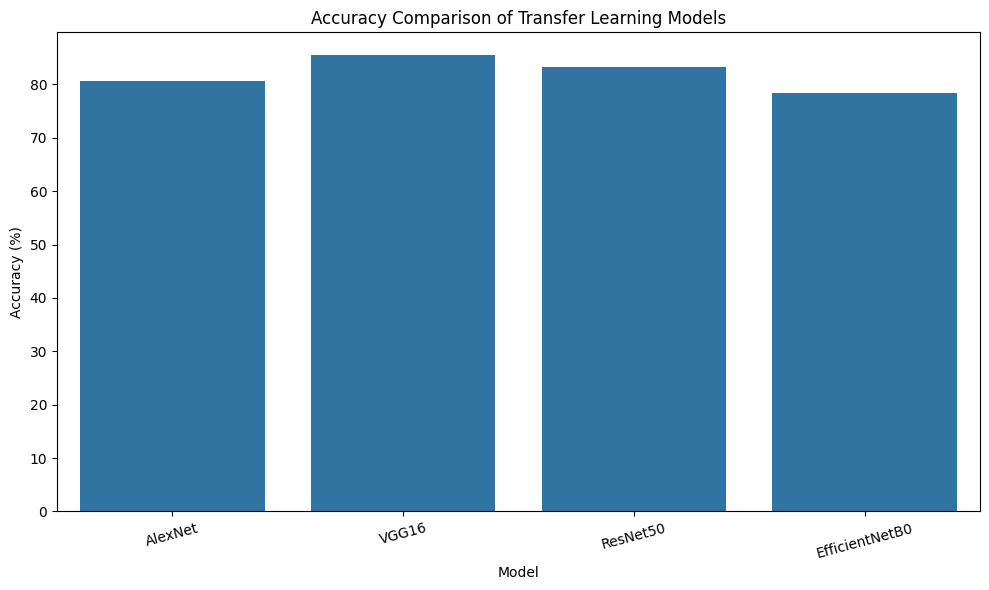

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=results_df.index,
    y=results_df["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Accuracy Comparison of Transfer Learning Models"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

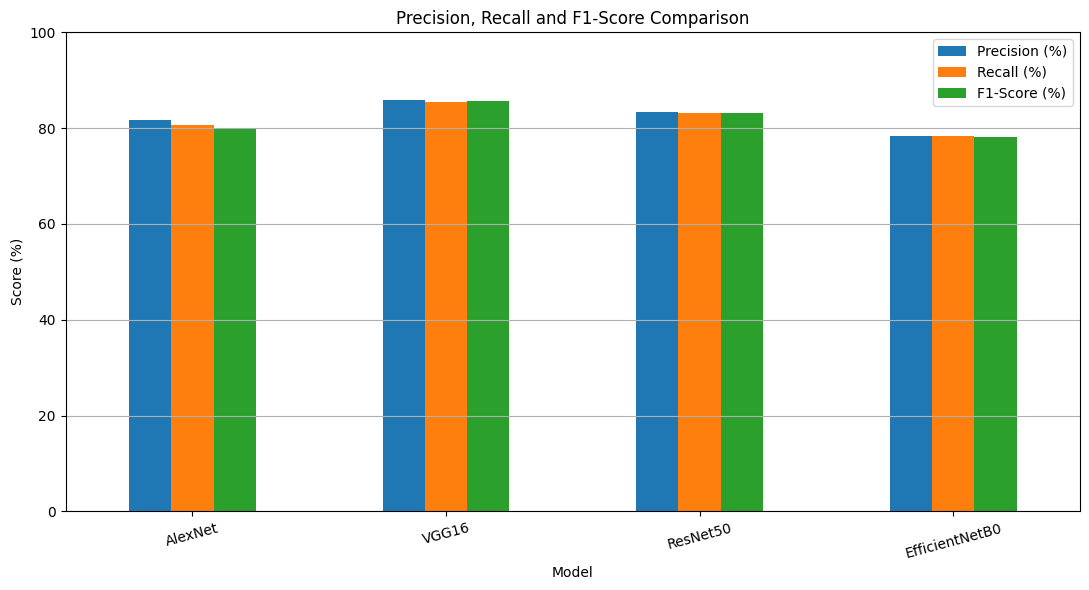

In [ ]:
metrics_to_plot = [
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)"
]

results_df[
    metrics_to_plot
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Model")
plt.ylabel("Score (%)")

plt.title(
    "Precision, Recall and F1-Score Comparison"
)

plt.xticks(rotation=15)

plt.ylim(0, 100)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

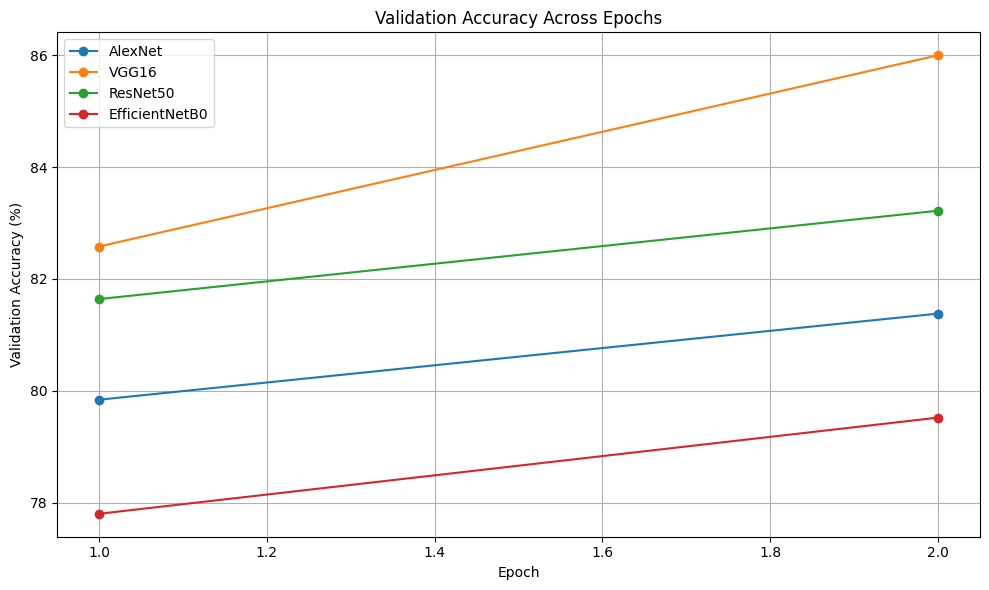

In [ ]:
plt.figure(figsize=(10, 6))

for model_name, history in histories.items():

    plt.plot(
        range(
            1,
            len(
                history["val_accuracy"]
            ) + 1
        ),
        np.array(
            history["val_accuracy"]
        ) * 100,
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Across Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

In [ ]:
for model_name, model in models_dict.items():

    (
        y_true,
        y_pred,
        accuracy,
        precision,
        recall,
        f1
    ) = evaluate_model(
        model,
        test_loader
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

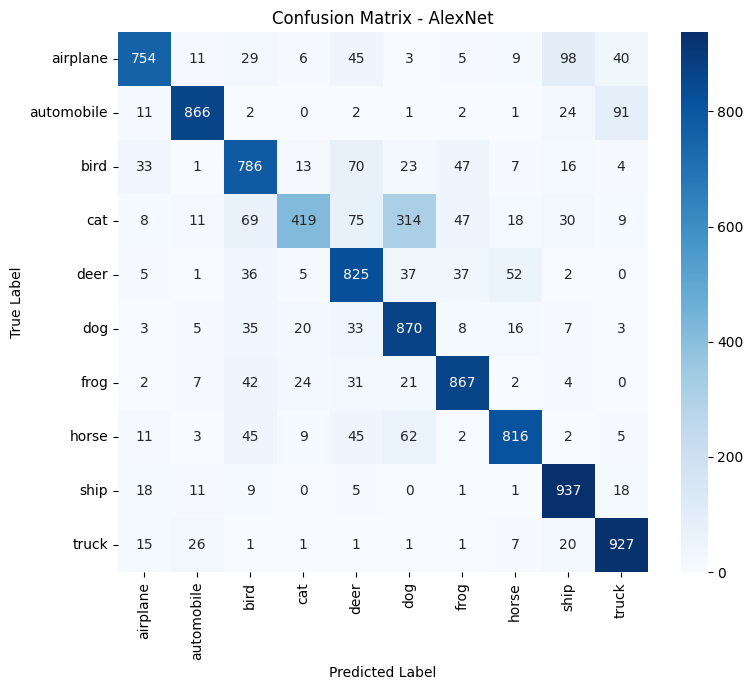

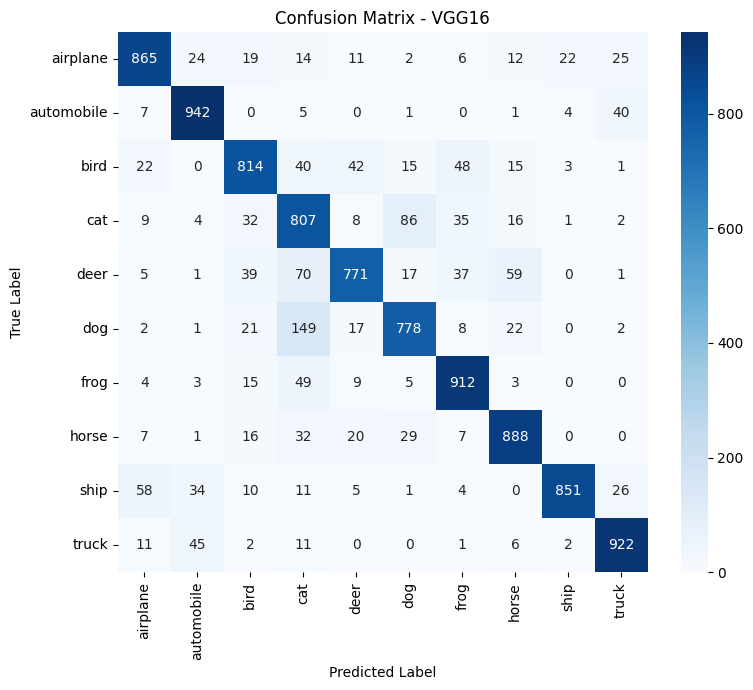

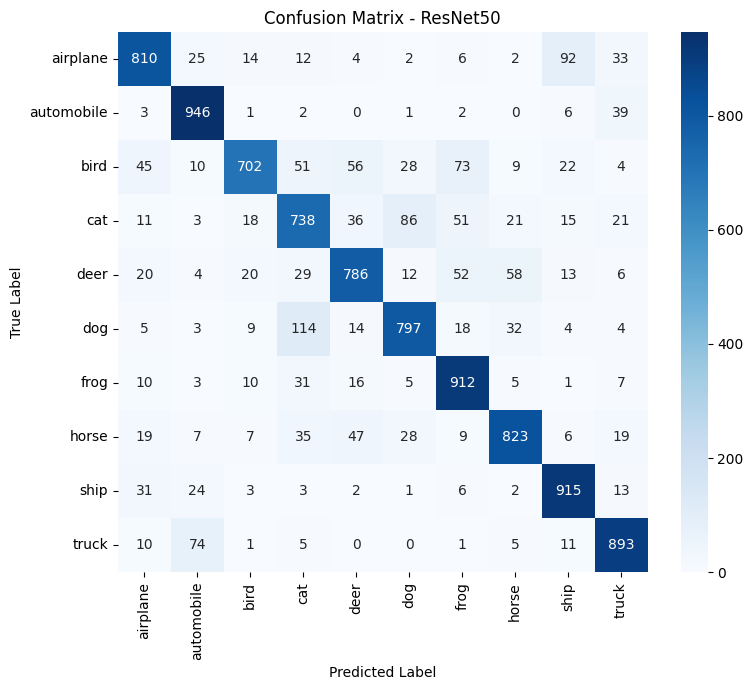

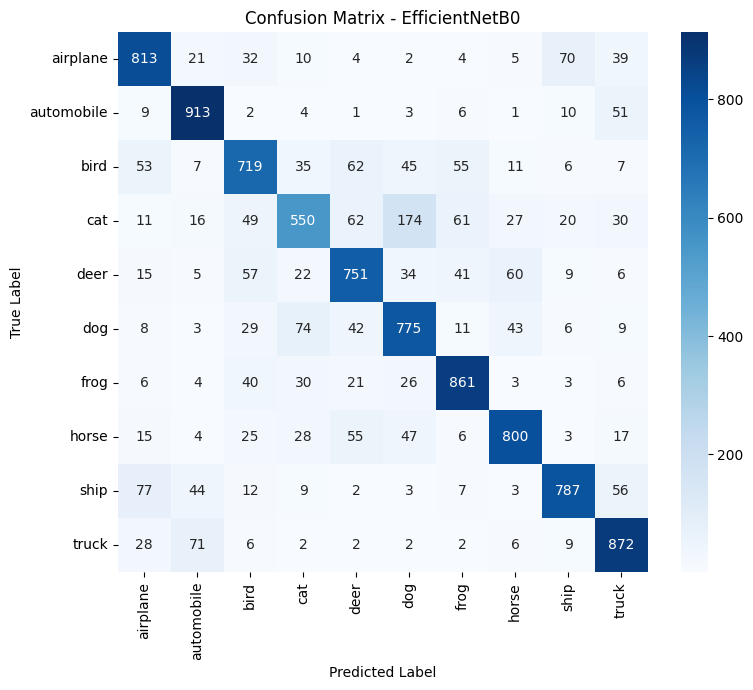

In [ ]:
for model_name, model in models_dict.items():

    (
        y_true,
        y_pred,
        accuracy,
        precision,
        recall,
        f1
    ) = evaluate_model(
        model,
        test_loader
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(8, 7)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    plt.show()

In [ ]:
results_df.to_csv(
    "CIFAR10_Transfer_Learning_Results.csv"
)

print(
    "Results saved successfully."
)

print(
    "\nSaved file:"
)

print(
    "CIFAR10_Transfer_Learning_Results.csv"
)

Results saved successfully.

Saved file:
CIFAR10_Transfer_Learning_Results.csv


In [ ]:
best_model_name = results_df[
    "Accuracy (%)"
].idxmax()

best_accuracy = results_df.loc[
    best_model_name,
    "Accuracy (%)"
]

print(
    "Best model based on test accuracy:",
    best_model_name
)

print(
    f"Accuracy: {best_accuracy:.2f}%"
)

Best model based on test accuracy: VGG16
Accuracy: 85.50%


In [ ]:
print("=" * 70)
print("FINAL TRANSFER LEARNING RESULTS")
print("=" * 70)

display(
    results_df.round(2)
)

print(
    "\nBest model:",
    best_model_name
)

print(
    f"Best test accuracy: {best_accuracy:.2f}%"
)

FINAL TRANSFER LEARNING RESULTS


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Training Time (min)
AlexNet,80.67,81.65,80.67,80.13,3.27
VGG16,85.50,85.92,85.50,85.56,9.57
ResNet50,83.22,83.37,83.22,83.09,5.59
EfficientNetB0,78.41,78.34,78.41,78.18,3.69



Best model: VGG16
Best test accuracy: 85.50%
